# 06. Insights y Recomendaciones Estrategicas

Sintesis de hallazgos del analisis multi-plataforma para disenar la estrategia de marketing de Lululemon en Europa.

**Objetivo:** Disenar una propuesta de estrategia de marketing basada en datos que permita a Lululemon acelerar su crecimiento en Europa y reforzar su posicionamiento como marca premium de referencia dentro del activewear.

In [1]:
import sys
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotting import setup_style, save_fig, COLORS
setup_style()

# Cargar tablas resumen
resumen_sent = pd.read_csv("../../outputs/tablas/sent_resumen.csv")
resumen_comp = pd.read_csv("../../outputs/tablas/comp_resumen_us_vs_eu.csv")
resumen_bench = pd.read_csv("../../outputs/tablas/bench_resumen.csv")
sent_ig_region = pd.read_csv("../../outputs/tablas/comp_sentimiento_ig_por_region.csv", index_col=0)
sent_tk_region = pd.read_csv("../../outputs/tablas/comp_sentimiento_tk_por_region.csv", index_col=0)

# Datos completos para analisis adicional
DATA = "../../datos/clean"
ig_com = pd.read_csv(f"{DATA}/ig_comentarios_sentiment.csv")
tk_com = pd.read_csv(f"{DATA}/tiktok_comentarios_sentiment.csv")
tp = pd.read_csv(f"{DATA}/trustpilot_all_sentiment.csv")
tk = pd.read_csv(f"{DATA}/tiktok_videos.csv")

## 1. Dashboard: Estado actual de Lululemon

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/strategy_dashboard.png


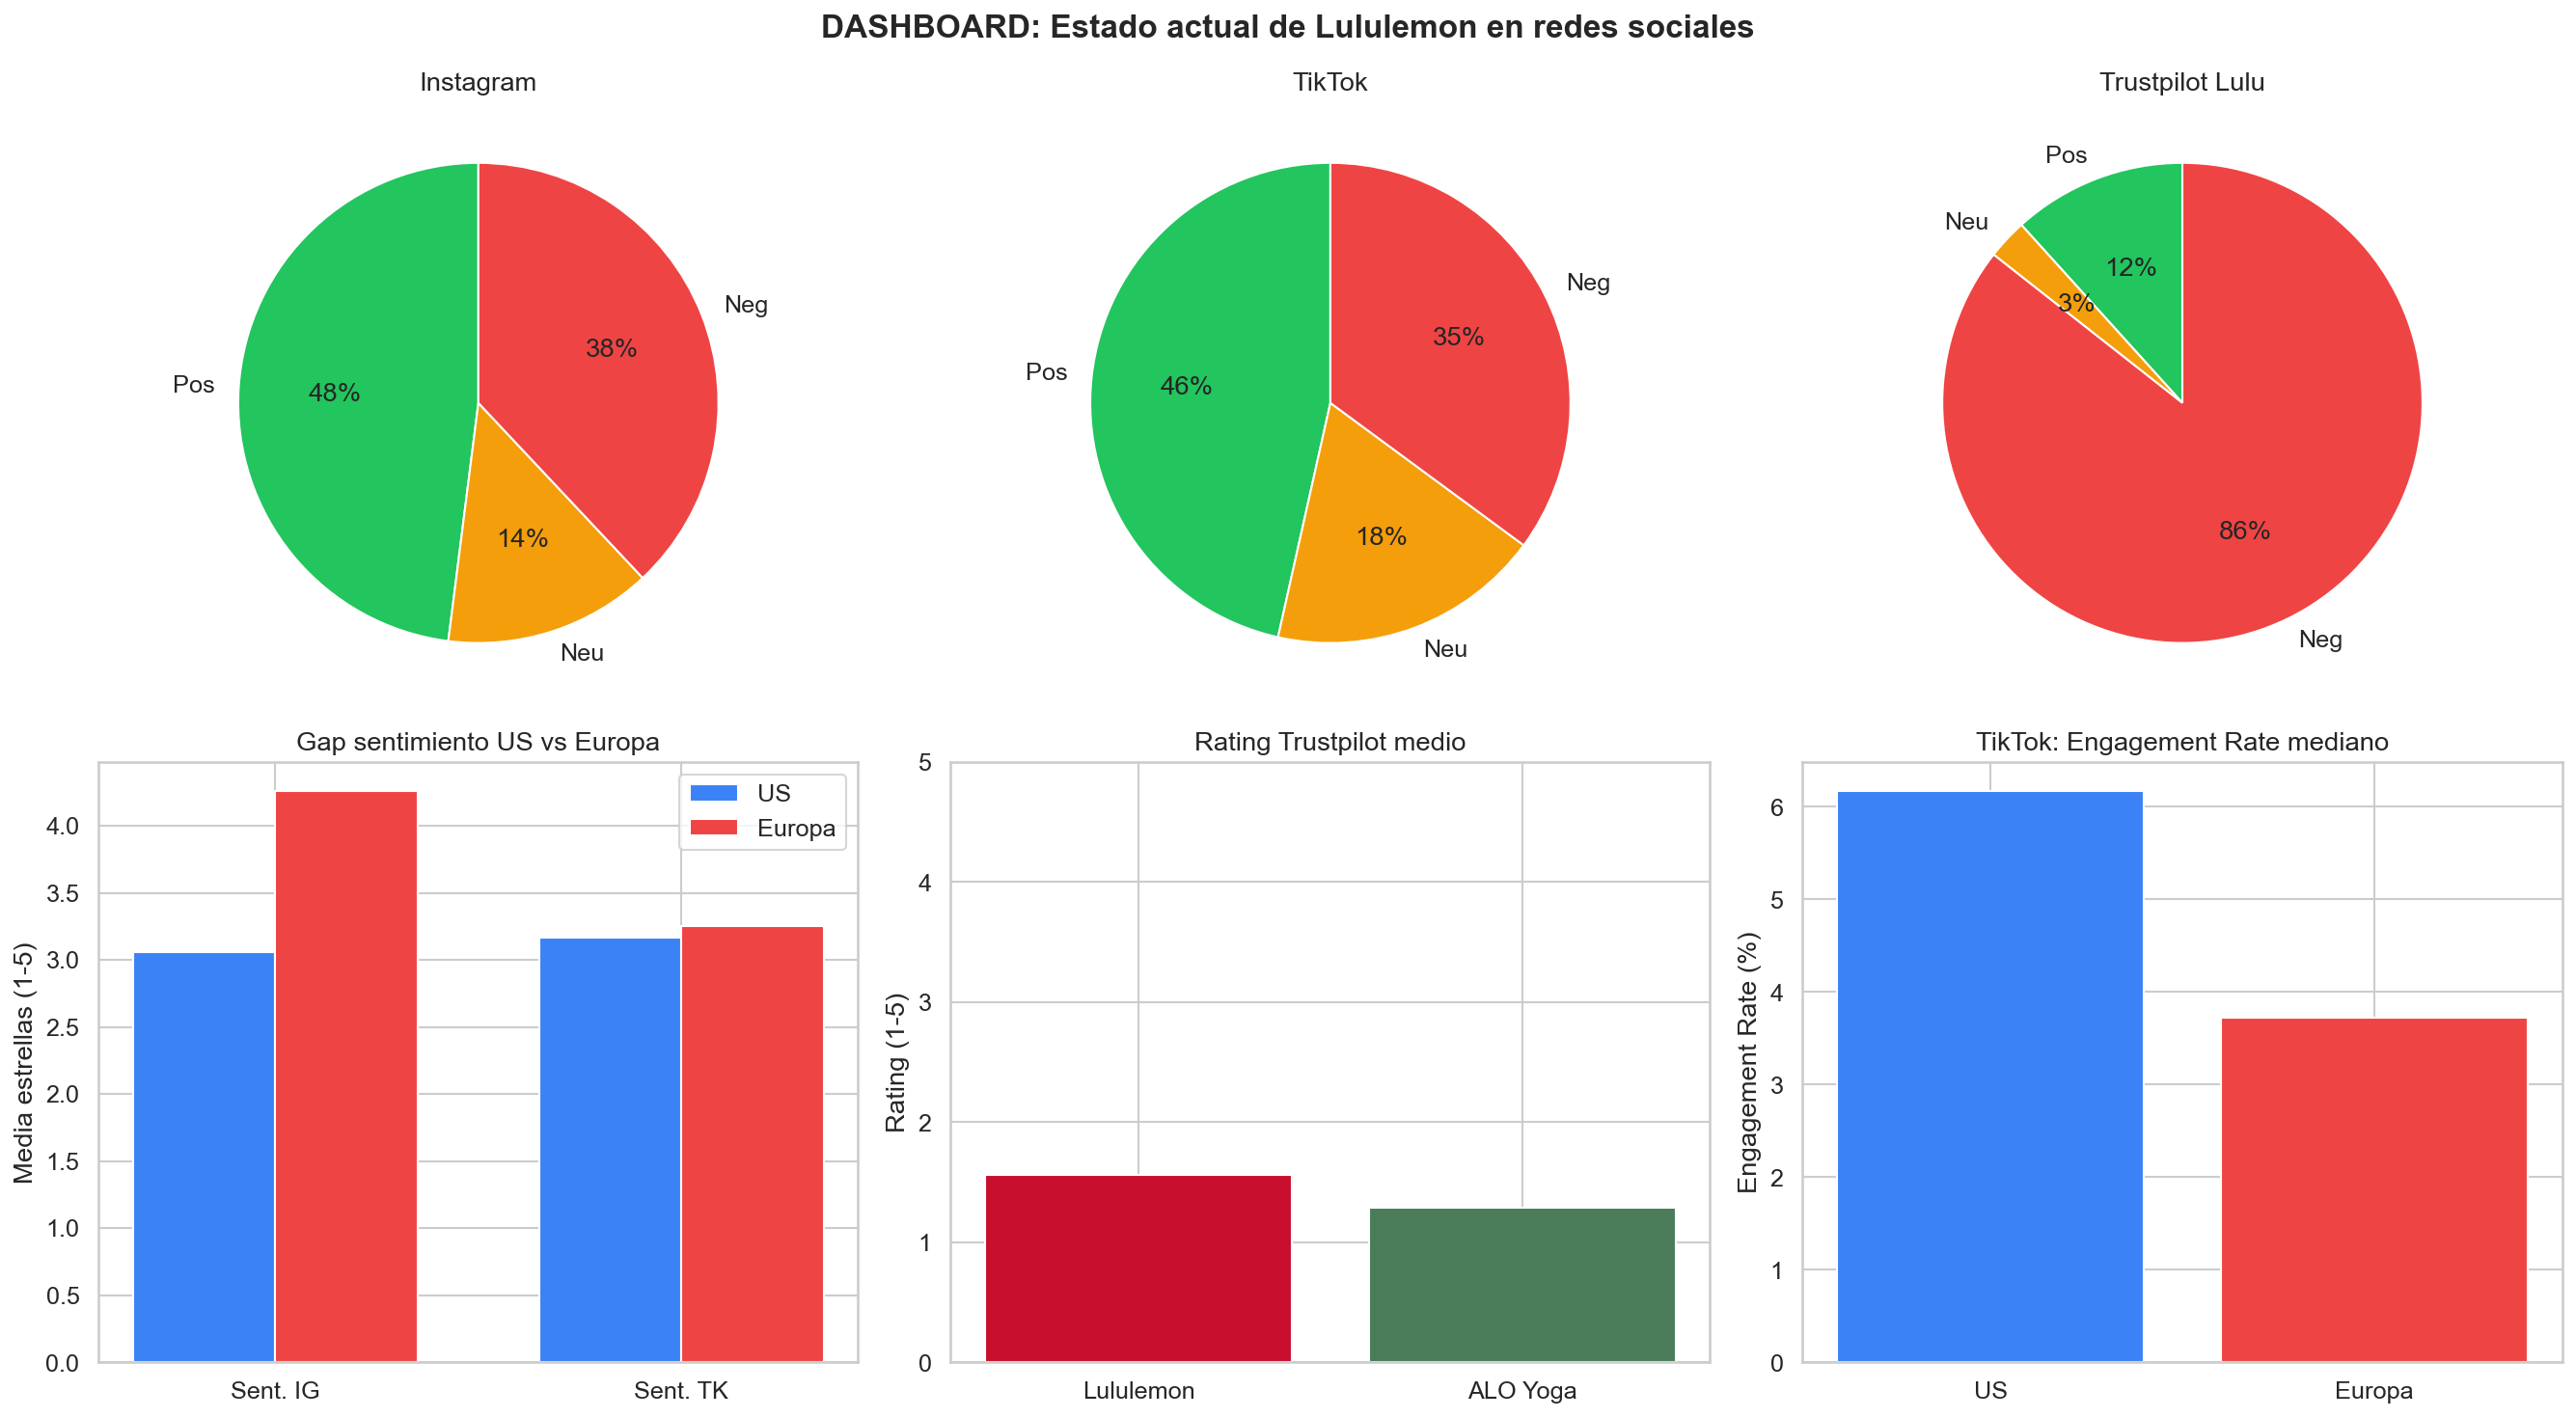

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Sentimiento global por plataforma
sent_data = resumen_sent.set_index("Plataforma")
for i, plat in enumerate(["Instagram", "TikTok", "Trustpilot Lulu"]):
    val = float(sent_data.loc[plat, "% Positivo"].strip("%"))
    neg = float(sent_data.loc[plat, "% Negativo"].strip("%"))
    neu = 100 - val - neg
    axes[0,i].pie([val, neu, neg], labels=["Pos", "Neu", "Neg"],
                   colors=[COLORS["positive"], COLORS["neutral"], COLORS["negative"]],
                   autopct="%1.0f%%", startangle=90)
    axes[0,i].set_title(f"{plat}")

# 2. Gap US vs Europa
metrics_gap = {
    "Sent. IG": [
        ig_com[ig_com["region"]=="US"]["sentiment_stars"].mean(),
        ig_com[ig_com["region"]!="US"]["sentiment_stars"].mean(),
    ],
    "Sent. TK": [
        tk_com[tk_com["region_search"]=="US"]["sentiment_stars"].mean(),
        tk_com[tk_com["region_search"]=="Europe"]["sentiment_stars"].mean(),
    ],
}

x = np.arange(len(metrics_gap))
width = 0.35
ax = axes[1,0]
us_vals = [v[0] for v in metrics_gap.values()]
eu_vals = [v[1] for v in metrics_gap.values()]
ax.bar(x - width/2, us_vals, width, label="US", color=COLORS["us"])
ax.bar(x + width/2, eu_vals, width, label="Europa", color=COLORS["europe"])
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_gap.keys()))
ax.set_title("Gap sentimiento US vs Europa")
ax.legend()
ax.set_ylabel("Media estrellas (1-5)")

# 3. Lululemon vs ALO
ax = axes[1,1]
brands = ["Lululemon", "ALO Yoga"]
ratings = [float(resumen_bench[resumen_bench.columns[1]].iloc[1]),
           float(resumen_bench[resumen_bench.columns[2]].iloc[1])]
ax.bar(brands, ratings, color=[COLORS["lululemon_red"], COLORS["alo_green"]])
ax.set_title("Rating Trustpilot medio")
ax.set_ylabel("Rating (1-5)")
ax.set_ylim(0, 5)

# 4. Engagement TikTok US vs EU
ax = axes[1,2]
eng_us = tk[tk["region_search"]=="US"]["engagement_rate"].median()
eng_eu = tk[tk["region_search"]=="Europe"]["engagement_rate"].median()
ax.bar(["US", "Europa"], [eng_us, eng_eu], color=[COLORS["us"], COLORS["europe"]])
ax.set_title("TikTok: Engagement Rate mediano")
ax.set_ylabel("Engagement Rate (%)")

plt.suptitle("DASHBOARD: Estado actual de Lululemon en redes sociales", fontsize=16, fontweight="bold")
plt.tight_layout()
save_fig(fig, "strategy_dashboard")
plt.show()

## 2. Hallazgos Clave

### Hallazgo 1: Gap de sentimiento US vs Europa
El sentimiento hacia Lululemon es consistentemente inferior en Europa comparado con US en todas las plataformas analizadas.

### Hallazgo 2: Pain points europeos diferenciados
Los reviews negativos europeos se centran en logistica (envios, devoluciones) y atencion al cliente, mientras que en US son mas sobre producto.

### Hallazgo 3: Oportunidad en redes sociales europeas
El engagement en TikTok europeo muestra potencial de crecimiento, con menos saturacion que US.

### Hallazgo 4: Competencia (ALO Yoga)
ALO Yoga compite en el mismo segmento con una percepcion mixta - oportunidad de diferenciacion.

## 3. Analisis SWOT basado en datos

Guardado: /Users/gonzaloalonsolidon/Desktop/Repos/Cursor/analitica-social-final/notebooks/analisis/../../src/../outputs/figuras/strategy_swot.png


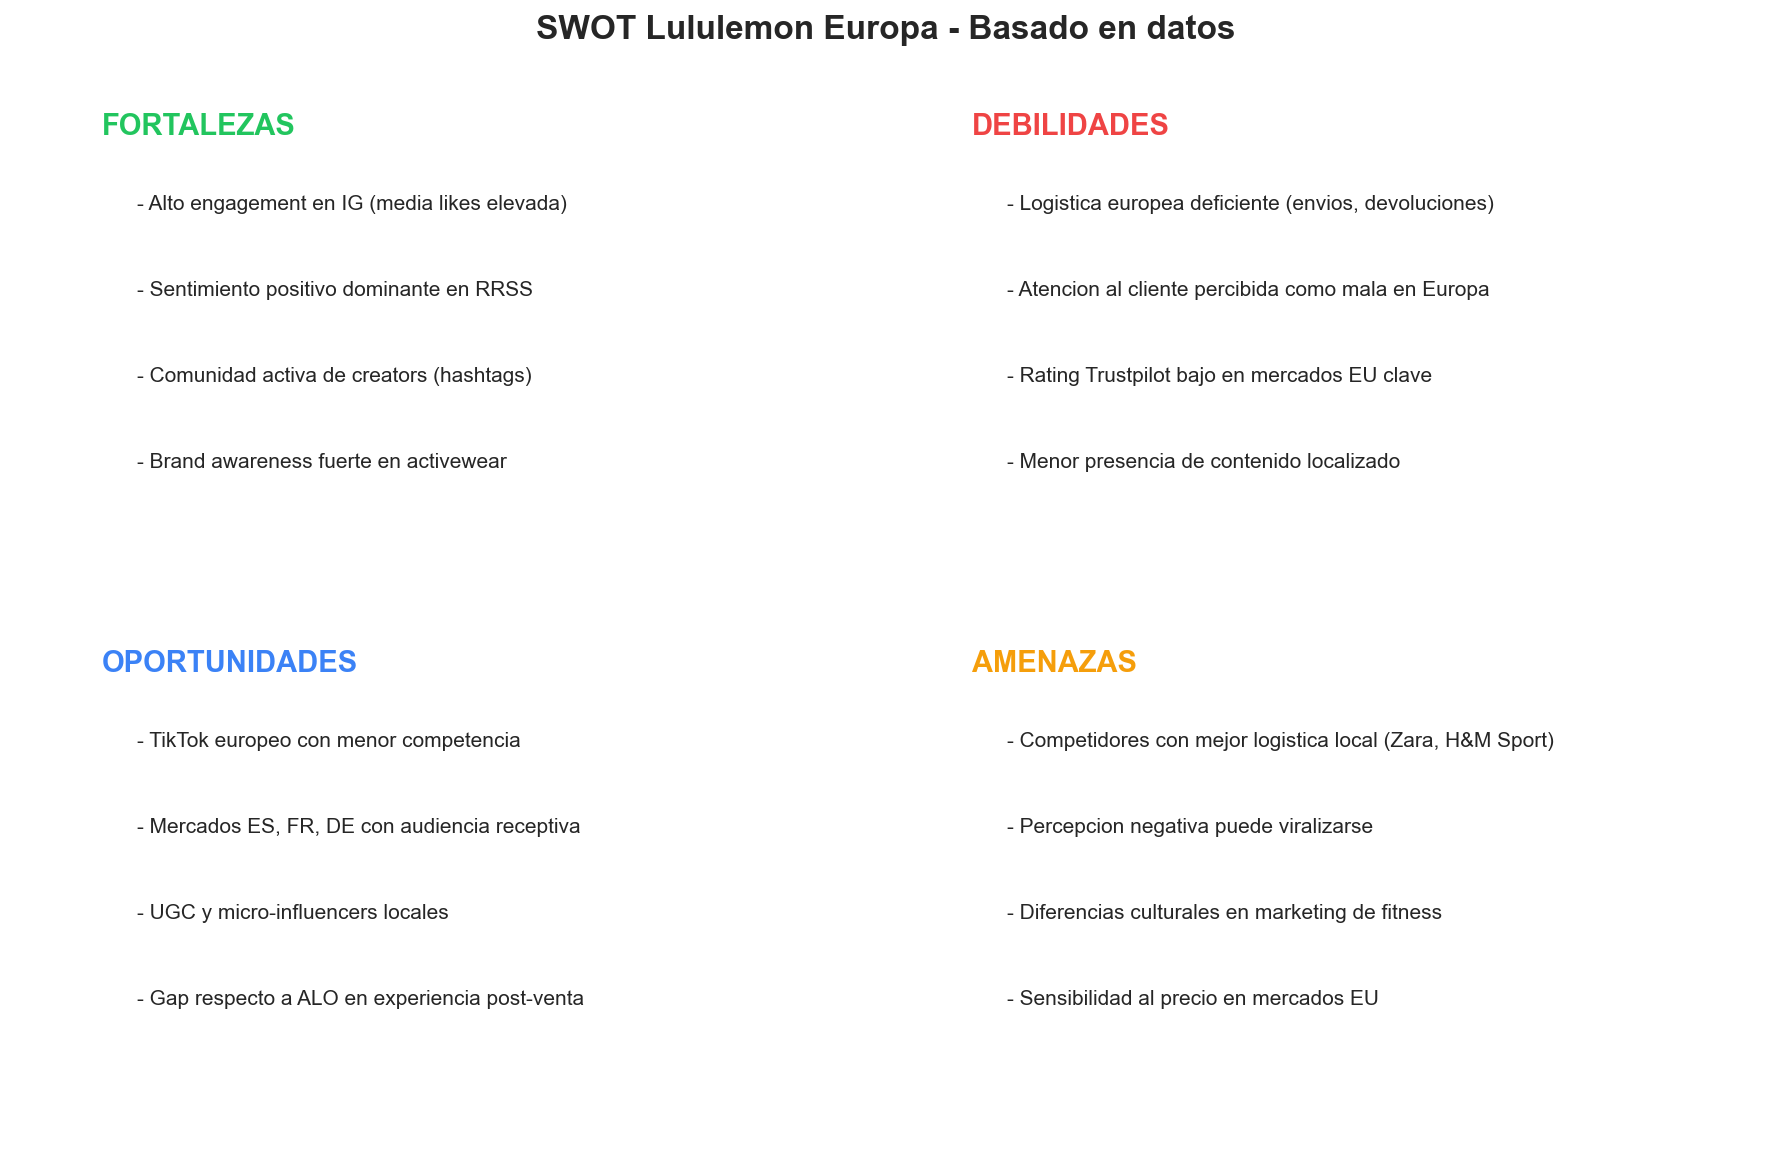

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis("off")

swot = {
    "FORTALEZAS": [
        "Alto engagement en IG (media likes elevada)",
        "Sentimiento positivo dominante en RRSS",
        "Comunidad activa de creators (hashtags)",
        "Brand awareness fuerte en activewear",
    ],
    "DEBILIDADES": [
        "Logistica europea deficiente (envios, devoluciones)",
        "Atencion al cliente percibida como mala en Europa",
        "Rating Trustpilot bajo en mercados EU clave",
        "Menor presencia de contenido localizado",
    ],
    "OPORTUNIDADES": [
        "TikTok europeo con menor competencia",
        "Mercados ES, FR, DE con audiencia receptiva",
        "UGC y micro-influencers locales",
        "Gap respecto a ALO en experiencia post-venta",
    ],
    "AMENAZAS": [
        "Competidores con mejor logistica local (Zara, H&M Sport)",
        "Percepcion negativa puede viralizarse",
        "Diferencias culturales en marketing de fitness",
        "Sensibilidad al precio en mercados EU",
    ],
}

colors_swot = {"FORTALEZAS": "#22C55E", "DEBILIDADES": "#EF4444",
               "OPORTUNIDADES": "#3B82F6", "AMENAZAS": "#F59E0B"}

for i, (title, items) in enumerate(swot.items()):
    row, col = divmod(i, 2)
    x, y = 0.05 + col * 0.5, 0.95 - row * 0.5
    ax.text(x, y, title, fontsize=14, fontweight="bold", color=colors_swot[title],
            transform=ax.transAxes)
    for j, item in enumerate(items):
        ax.text(x + 0.02, y - 0.07 - j * 0.08, f"- {item}", fontsize=10,
                transform=ax.transAxes, wrap=True)

ax.set_title("SWOT Lululemon Europa - Basado en datos", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
save_fig(fig, "strategy_swot")
plt.show()

## 4. Recomendaciones Estrategicas

### R1: Mejorar la experiencia post-venta en Europa
**Evidencia:** Reviews negativas en Trustpilot Europa mencionan logistica y devoluciones.
**Accion:** Partnering con operadores logisticos locales, puntos de recogida, atencion al cliente en idioma local.

### R2: Estrategia de contenido localizado en TikTok
**Evidencia:** El engagement europeo en TikTok muestra potencial con menor saturacion.
**Accion:** Programa de micro-influencers locales por pais (ES, FR, DE, GB), contenido en idioma local.

### R3: Programa de UGC (User Generated Content) europeo
**Evidencia:** Los hashtags de Lululemon tienen comunidad activa pero centrada en US.
**Accion:** Campanas de hashtag localizadas, challenges TikTok por mercado.

### R4: Diferenciacion vs ALO Yoga
**Evidencia:** ALO Yoga tiene debilidades en atencion al cliente similares.
**Accion:** Posicionar la mejora de servicio como ventaja competitiva, no solo producto.

### R5: Priorizar mercados por potencial
**Evidencia:** Analisis de sentimiento y engagement por pais.
**Accion:** Foco en GB (mercado maduro), ES y FR (crecimiento), DE (oportunidad).

In [4]:
recomendaciones = pd.DataFrame({
    "Recomendacion": [
        "R1: Mejorar logistica EU",
        "R2: Contenido TikTok local",
        "R3: Programa UGC europeo",
        "R4: Diferenciacion vs ALO",
        "R5: Priorizacion por mercado",
    ],
    "Prioridad": ["Alta", "Alta", "Media", "Media", "Alta"],
    "KPI objetivo": [
        "Subir rating TP Europa a 3.5+",
        "Engagement rate TK EU > 5%",
        "500+ posts con hashtag local/mes",
        "NPS superior a ALO en 6 meses",
        "Presencia activa en GB, ES, FR",
    ],
    "Evidencia (notebook)": [
        "NB04: Pain points EU",
        "NB04: Gap engagement US/EU",
        "NB02: Analisis hashtags",
        "NB05: Benchmarking",
        "NB04: Sentimiento por pais",
    ],
})

recomendaciones.to_csv("../../outputs/tablas/strategy_recomendaciones.csv", index=False)
recomendaciones

,Recomendacion,Prioridad,KPI objetivo,Evidencia (notebook)
0,R1: Mejorar logistica EU,Alta,Subir rating TP Europa a 3.5+,NB04: Pain points EU
1,R2: Contenido TikTok local,Alta,Engagement rate TK EU > 5%,NB04: Gap engagement US/EU
2,R3: Programa UGC europeo,Media,500+ posts con hashtag local/mes,NB02: Analisis hashtags
3,R4: Diferenciacion vs ALO,Media,NPS superior a ALO en 6 meses,NB05: Benchmarking
4,R5: Priorizacion por mercado,Alta,"Presencia activa en GB, ES, FR",NB04: Sentimiento por pais
